In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np

csv_path = "../output/benchmark_summary.csv"
if not os.path.exists(csv_path):
    print(f"Error: {csv_path} couldn't be found")

else:
    #load the benchmark content
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded the benchmark content for {len(df)} models")
    display(df.head())

Successfully loaded the benchmark content for 11 models


,model,total_questions,accuracy_pct,avg_score,hallucination_pct,avg_latency_ms,total_prompt_tokens,total_completion_tokens,total_cost_usd
0,openai/gpt-4o-mini,150,74.67,83.30,24.67,2265.86,251918,10273,0.0440
1,google/gemini-2.5-flash,150,71.33,83.90,28.67,1966.19,288348,13055,0.1191
2,google/gemini-2.5-flash-lite,150,78.00,82.73,7.33,1359.82,288348,10610,0.0331
3,meta-llama/llama-3.3-70b-instruct,150,83.33,87.97,10.67,4128.97,255655,15237,0.0304
4,meta-llama/llama-3.2-3b-instruct,150,56.00,64.97,17.33,1470.70,199376,10717,0.0135


C:\Users\alexh\AppData\Local\Temp\ipykernel_41756\1857474622.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(df_acc["model"], rotation = 45, ha = "right")


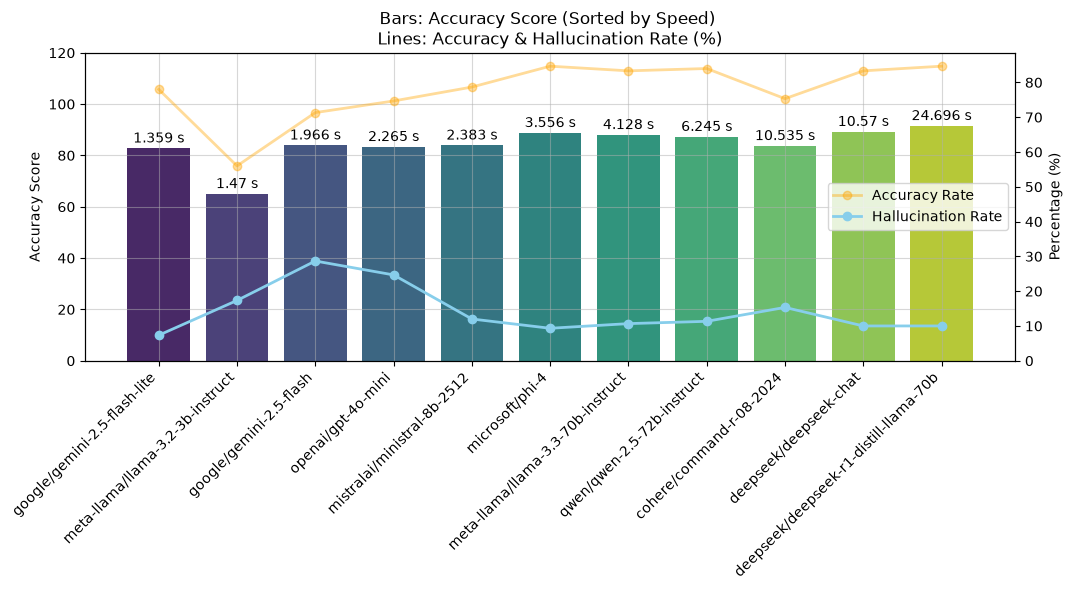

In [95]:
df_acc = df.sort_values(by = "avg_latency_ms", ascending = True)

_, ax1 = plt.subplots(figsize = (12, 4))
sns.barplot(
    data = df_acc,
    x = "model",
    hue = "model",
    y = "avg_score",
    ax = ax1,
    palette = "viridis",
    legend = False,
)
#Add latency to the top of the bar 
for i, (_, row) in enumerate(df_acc.iterrows()):
    ax1.text(
        x = i,
        y = row["avg_score"] + 1,
        s = f"{int (row['avg_latency_ms']) / 1e3} s",
        ha = "center",
        va = "bottom",
    )

ax1.set_ylabel("Accuracy Score")
ax1.set_xticklabels(df_acc["model"], rotation = 45, ha = "right")
ax1.grid(True, alpha= 0.5)
ax1.set_xlabel("")
ax1.set_ylim(0, 120)

ax2 = ax1.twinx()
#Add linegraph for accuracy percentage
ax2.plot(
    df_acc["model"],
    df_acc["accuracy_pct"],
    color = "orange",
    marker = "o",
    linewidth = 2,
    label = "Accuracy Rate",
    alpha = 0.4
)

#Add linegraph for hallucination percentage
ax2.plot(
    df_acc["model"],
    df_acc["hallucination_pct"],
    color = "skyblue",
    marker = "o",
    linewidth = 2,
    label = "Hallucination Rate"
)

ax2.set_ylabel("Percentage (%)")
ax2.set_yticks(np.arange(0, 81, 10))
plt.title("Bars: Accuracy Score (Sorted by Speed) \n" \
        "Lines: Accuracy & Hallucination Rate (%)")
plt.legend(loc = "center right")
plt.show()

C:\Users\alexh\AppData\Local\Temp\ipykernel_41756\3922665623.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(df_cost["model"], rotation = 45, ha = "right")


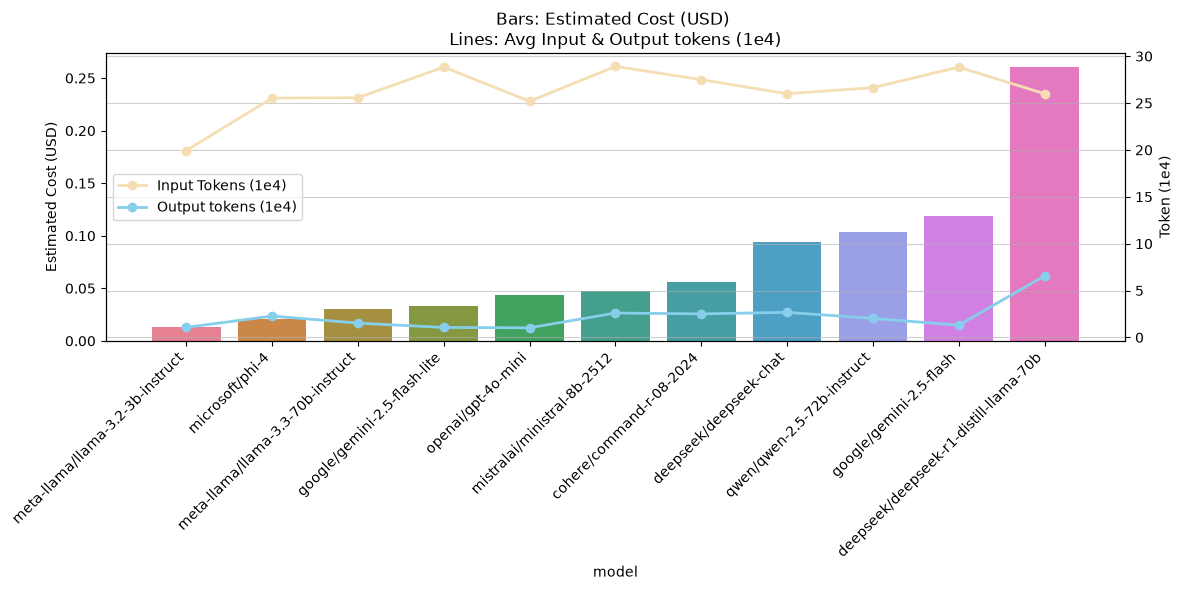

In [96]:
# Sort Data Frame by estimated cost in ascending order
df_cost = df.sort_values(by = "total_cost_usd", ascending=True)

#Plot estimated cost 
_, ax1 = plt.subplots(figsize = (12, 6))
sns.barplot(
    data = df_cost,
    x = "model",
    y = "total_cost_usd",
    ax = ax1,
    hue = "model",
    legend = False,
)
ax1.set_xticklabels(df_cost["model"], rotation = 45, ha = "right")
ax1.set_ylabel("Estimated Cost (USD)")

#Plot average input token cost
ax2 = ax1.twinx()
ax2.grid(True, alpha = 0.6)
ax2.plot(
    df_cost["model"],
    df_cost["total_prompt_tokens"] / int(1e4),
    marker = 'o',
    color = "wheat",
    linewidth = 2,
    label = "Input Tokens (1e4)"
)

#plot average output token cost 
ax2.plot(
    df_cost["model"],
    df_cost["total_completion_tokens"] / int(1e4),
    marker = 'o',
    linewidth = 2,
    color = "skyblue",
    label = "Output tokens (1e4)",
)
ax2.set_ylabel("Token (1e4)")

plt.legend(loc = 'center left')
plt.title("Bars: Estimated Cost (USD) \n" \
        "Lines: Avg Input & Output tokens (1e4)")
plt.tight_layout()
plt.show()